# Validation methods

Author <alberto.suarez@uam.es>

from Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.

https://scikit-learn.org/stable/modules/cross_validation.html

https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html#sphx-glr-auto-examples-model-selection-plot-grid-search-digits-py

In [1]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn import datasets
from sklearn.svm import SVC
import matplotlib.pyplot as plt

In [2]:
# Regression problem: Predict the price of a house
dataset = datasets.load_boston() 
X = dataset.data
threshold = np.percentile(dataset.target, 50)
y = dataset.target > threshold
print(np.shape(X), np.shape(y))

(506, 13) (506,)


### Model evaluation: Simple validation

In [3]:
test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=test_size,
    # random_state=0, # For reproducibility
    shuffle=True, # Data is randomly permuted before partition
    stratify=None # Stratified sampling
)

validation_size = test_size/(1.0 - test_size)

X_train_train, X_train_validation, y_train_train, y_train_validation = train_test_split(
    X_train, 
    y_train, 
    test_size=validation_size, 
)

print('Training data = [{}, {}]'.format(
    np.shape(X_train_train),
    np.shape(y_train_train),
))

print('Validation data = [{}, {}]'.format(
    np.shape(X_train_validation),
    np.shape(y_train_validation),
))

print('Test data = [{}, {}]'.format(
    np.shape(X_test),
    np.shape(y_test),
))

C = 1.0

# Train on (X_train_train, y_train_train)
clf = SVC(kernel='rbf', gamma=1.0e-2, C=C).fit(X_train_train, y_train_train)
# Evaluate on validation set
error_train = 1.0 - clf.score(X_train, y_train)
error_validation = 1.0 - clf.score(X_train_validation, y_train_validation)
error_test = 1.0 - clf.score(X_test, y_test)

print(r'Error (train) = {:.4f}'.format(error_train))
print(r'Error (validation) = {:.4f}'.format(error_validation))
print(r'Error (test) = {:.4f}'.format(error_test))


Training data = [(303, 13), (303,)]
Validation data = [(101, 13), (101,)]
Test data = [(102, 13), (102,)]
Error (train) = 0.0817
Error (validation) = 0.2871
Error (test) = 0.1863


100 

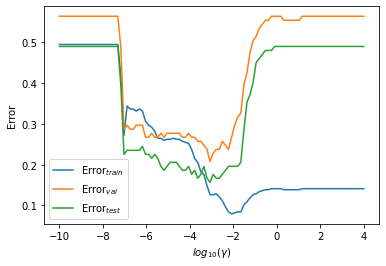

Minimum test error = 0.1569


In [4]:
gammas = np.logspace(-10, 4, 100)
error_train = np.empty(len(gammas))
error_validation = np.empty(len(gammas))
error_test = np.empty(len(gammas))

for i, gamma in enumerate(gammas):
    if np.mod(i,100) == 0:
        print(len(gammas) - i, end=' ')
    clf = SVC(kernel='rbf', gamma=gamma, C=C).fit(X_train_train, y_train_train)
    error_train[i] = 1.0 - clf.score(X_train, y_train)
    error_validation[i] = 1.0 - clf.score(X_train_validation, y_train_validation)
    error_test[i] = 1.0 - clf.score(X_test, y_test)
    
error_test_minimum = np.min(error_test)

fig, ax = plt.subplots()
log10_gamma = np.log10(gammas)

ax.plot(log10_gamma, error_train, label='Error$_{train}$')
ax.plot(log10_gamma, error_validation, label='Error$_{val}$')
ax.plot(log10_gamma, error_test, label='Error$_{test}$')

ax.set_xlabel('$log_{10}(\gamma)$')
ax.set_ylabel('Error')
ax.legend()
plt.show()
print('Minimum test error = {:.4f}'.format(error_test_minimum) )

### Model evaluation: k-fold cross-validation

#### Cross-validation splits

In [5]:
kf = KFold(n_splits=5, shuffle=False)
kf.get_n_splits(X)
print(kf)

KFold(n_splits=5, random_state=None, shuffle=False)


In [6]:
for i, (train_indices, test_indices) in enumerate(kf.split(X)):
    print('\nSPLIT {}:'.format(i))
    print("Cre samples:", test_indices)
    print("Training samples:", train_indices) 


SPLIT 0:
Cre samples: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101]
Training samples: [102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119
 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155
 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173
 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191
 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209
 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227
 228 229 230 231 232 233 234 235 

In [7]:
#### Cross-validation scores.

In [8]:
from sklearn.model_selection import cross_val_score
clf = SVC(kernel='rbf', gamma=1.0e-2, C=C, random_state=0)
k = 10
errors_CV = 1.0 - cross_val_score(clf, X_train, y_train, cv=k)
print('Errors ({}-fold CV) = {}'.format(k, errors_CV))
print('Mean {}-fold CV error (stdev) = {:.4f} ({:.4f})'.format(
    k,
    np.mean(errors_CV), 
    np.std(errors_CV),
))

Errors (10-fold CV) = [0.26829268 0.2195122  0.14634146 0.36585366 0.25       0.275
 0.1        0.175      0.275      0.325     ]
Mean 10-fold CV error (stdev) = 0.2400 (0.0771)


In [9]:
####Dependence of CV-errors on classifier hyperparameters.

100 

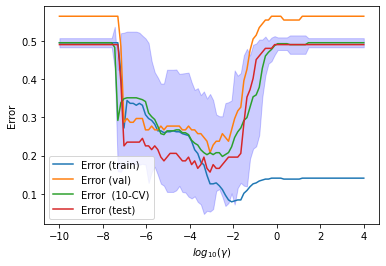

In [10]:
k = 10 # Number of cross-validation folds

error_CV = np.empty(len(gammas))
std_CV = np.empty(len(gammas))

for i, gamma in enumerate(gammas):
    if np.mod(i,100) == 0:
        print(len(gammas) - i, end=' ')
    clf = SVC(kernel='rbf', gamma=gamma, C=C)
    errors_CV = 1.0 - cross_val_score(clf, X_train, y_train, cv=k)
    error_CV[i] = np.mean(errors_CV)
    std_CV[i] = np.std(errors_CV)
    
fig, ax = plt.subplots()
log10_gamma = np.log10(gammas)

ax.plot(log10_gamma, error_train, label='Error (train)')
ax.plot(log10_gamma, error_validation, label='Error (val)')
ax.plot(log10_gamma, error_CV, label=r'Error  ({}-CV)'.format(k))
a = 2.0  # To plot confidence interval
ax.fill_between(
    log10_gamma,
    error_CV - a*std_CV, 
    error_CV + a*std_CV, 
    color='b', 
    alpha=0.2,
)
ax.plot(log10_gamma, error_test, label='Error (test)')

ax.set_xlabel('$log_{10}(\gamma)$')
ax.set_ylabel('Error')
ax.legend()
plt.show()

### Tuning hyperparameters and model selection using cross validation.

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Set the hyper parameters by cross-validation.
hyperparameters = [
    {
        'kernel': ['linear'], 
        'C': [0.1, 1.0, 10.0, 100.0],
    },
    {
        'kernel': ['rbf'],
        'gamma': [1.0e-4, 1.0e-3, 1.0e-2, ], 
        'C': [0.1, 1.0, 10.0, 100.0],
    }
]

clf = GridSearchCV(SVC(), hyperparameters, cv=5)
clf.fit(X_train, y_train)

print('Hyparameters that minimize the CV error:\n')
print(clf.best_params_)

Hyparameters that minimize the CV error:

{'C': 1.0, 'kernel': 'linear'}


In [12]:
print('Detailed classification report (train):\n')
y_predicted_train = clf.predict(X_train)
print(classification_report(y_train, y_predicted_train))
print()
    
print('Detailed classification report (test):\n')
y_predicted_test = clf.predict(X_test)
print(classification_report(y_test, y_predicted_test))
print()    

Detailed classification report (train):

              precision    recall  f1-score   support

       False       0.87      0.89      0.88       204
        True       0.89      0.86      0.88       200

    accuracy                           0.88       404
   macro avg       0.88      0.88      0.88       404
weighted avg       0.88      0.88      0.88       404


Detailed classification report (test):

              precision    recall  f1-score   support

       False       0.85      0.90      0.88        52
        True       0.89      0.84      0.87        50

    accuracy                           0.87       102
   macro avg       0.87      0.87      0.87       102
weighted avg       0.87      0.87      0.87       102




In [13]:
errors_CV = clf.cv_results_['mean_test_score']
stds_CV = clf.cv_results_['std_test_score']

for error_CV, std_CV, params in zip(errors_CV, stds_CV, clf.cv_results_['params']):
    print('{:0.3f} (+/- {:0.3f}) for {}\n'.format(
        error_CV, 
        2.0 * std_CV, 
        params,
    ))


0.847 (+/- 0.070) for {'C': 0.1, 'kernel': 'linear'}

0.857 (+/- 0.077) for {'C': 1.0, 'kernel': 'linear'}

0.854 (+/- 0.083) for {'C': 10.0, 'kernel': 'linear'}

0.844 (+/- 0.050) for {'C': 100.0, 'kernel': 'linear'}

0.735 (+/- 0.095) for {'C': 0.1, 'gamma': 0.0001, 'kernel': 'rbf'}

0.755 (+/- 0.108) for {'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}

0.520 (+/- 0.050) for {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}

0.750 (+/- 0.082) for {'C': 1.0, 'gamma': 0.0001, 'kernel': 'rbf'}

0.804 (+/- 0.090) for {'C': 1.0, 'gamma': 0.001, 'kernel': 'rbf'}

0.750 (+/- 0.071) for {'C': 1.0, 'gamma': 0.01, 'kernel': 'rbf'}

0.792 (+/- 0.094) for {'C': 10.0, 'gamma': 0.0001, 'kernel': 'rbf'}

0.834 (+/- 0.060) for {'C': 10.0, 'gamma': 0.001, 'kernel': 'rbf'}

0.740 (+/- 0.096) for {'C': 10.0, 'gamma': 0.01, 'kernel': 'rbf'}

0.814 (+/- 0.017) for {'C': 100.0, 'gamma': 0.0001, 'kernel': 'rbf'}

0.792 (+/- 0.074) for {'C': 100.0, 'gamma': 0.001, 'kernel': 'rbf'}

0.745 (+/- 0.112) for {'C': 100.0, '

## What have we learned?

1. To provide an unbiased estimate of the generalization error, the evaluation of a predictor needs to be carried out in a test set that is independent of the training set.
2. The test set error estimate is unbiased but exhibits fluctuations (variance error) due to the limited amount of data available for estimation.
3. The training data can be partitioned into a set that is used to actually train the classifier (i.e. determine its parameters) and a validation set that is used to provide an unbiased estimate of the test error.
4. The partitions (folds) for cross-validation should be stratified (have the same class distribution as the original training data).
5. The CV estimate of the error is biased and has variance. The bias is smaller for larger values of $k$. The variance is larger for larger values of $k$.
6. A complex model (e.g. a non-linear SVM) need not be more accurate than a simpler one (e.g. a linear one). 

## Exercises.

1. In the validation example use `X_train, t_train` instead of `X_train_train, t_train_train` to train the predictor. Run the code and comment on the results.
2. Change $k$ in the k-fold cross-validation and comment on the depencence on $k$ of the results. In particular, how do the bias and the variance of the cross-validation error estimates depend on $k$? 
3. How can one use k-fold cross-validation to provide a leave-one-out (loo) estimate of the error. Plot curve of the loo error estimates and the uncertainty intervals for different values of the hyperparameters of the predictor.